In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

c:\Users\ASUS\anaconda3\envs\ml_prod_v01\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the processed dataset
df = pd.read_csv("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/data/processed/processed_data.csv")

print("Shape:", df.shape)

df.head()

Shape: (8000, 35)


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,x1_Referral,x1_SEO,x1_Social Media,x2_Awareness,x2_Consideration,x2_Conversion,x2_Retention,x3_IsConfid,x4_ToolConfid,Conversion
0,0.830400,1.391266,0.527784,-1.320998,-0.298267,-1.729507,-1.209000,-0.078303,-1.066014,-0.608829,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1
1,1.702775,-1.142380,-0.388643,0.010679,1.428427,1.205221,-1.010159,-0.562053,-1.550715,-1.309262,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
2,0.159343,0.101011,-1.217996,1.460971,-0.509946,-1.589758,1.026327,1.435737,-1.723823,0.266712,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
3,-0.780138,-1.080472,-1.573010,-0.205066,-0.298763,1.554594,-0.386987,1.647165,1.357493,-1.309262,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
4,1.098823,-0.018599,-1.171591,1.167504,0.101230,-1.729507,-1.344153,1.482702,-1.516094,-0.608829,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1


In [3]:
# Define features and target
X = df.drop("Conversion", axis=1)
y = df["Conversion"]

In [4]:
# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
# Load the saved model
model = joblib.load("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/models/ensemble_model_final.pkl")
print(model)

CalibratedClassifierCV(cv=3,
                       estimator=VotingClassifier(estimators=[('xgb',
                                                               XGBClassifier(base_score=None,
                                                                             booster=None,
                                                                             callbacks=None,
                                                                             colsample_bylevel=None,
                                                                             colsample_bynode=None,
                                                                             colsample_bytree=0.7,
                                                                             early_stopping_rounds=None,
                                                                             enable_categorical=False,
                                                                             eval_metric=None,
                    

In [6]:
# Extract ensemble from calibrated model
base_model = model.estimator

print(base_model)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rat...
                                            max_leaves=None,
           

In [7]:
# Create SHAP explainer
explainer = shap.Explainer(base_model.predict_proba, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

Permutation explainer: 1601it [2:36:11,  5.86s/it]                            


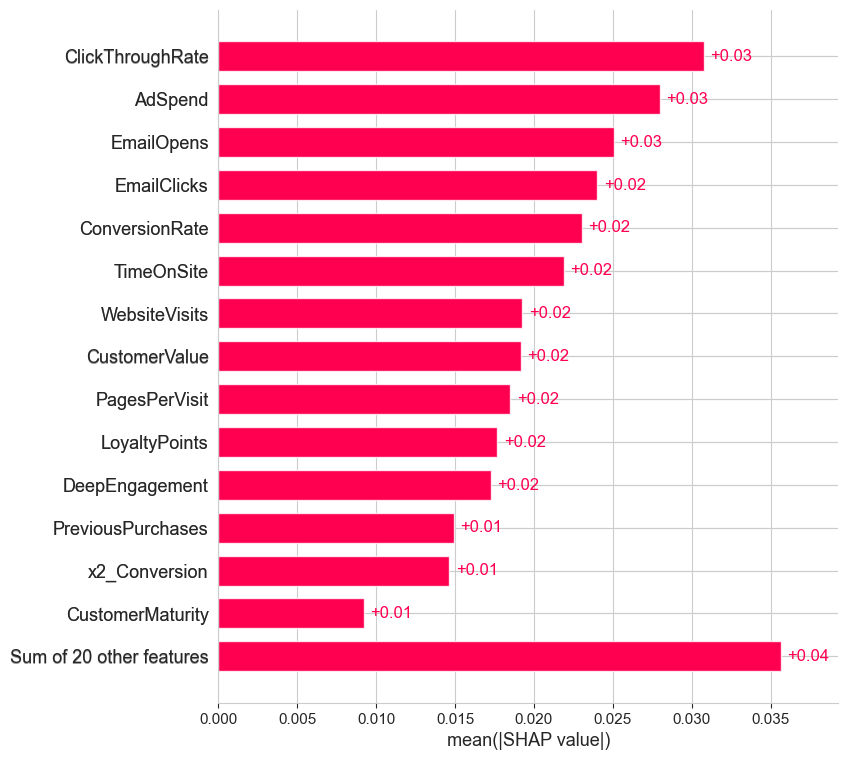

In [8]:
# Plot SHAP summary
shap.plots.bar(shap_values[:, :, 1], max_display=15)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


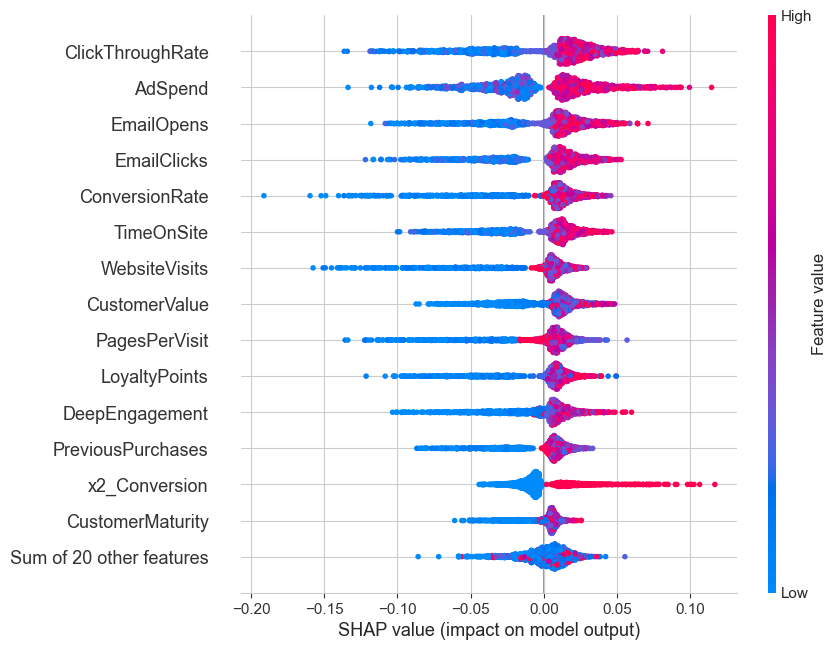

In [9]:
# Plot SHAP beeswarm
shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)

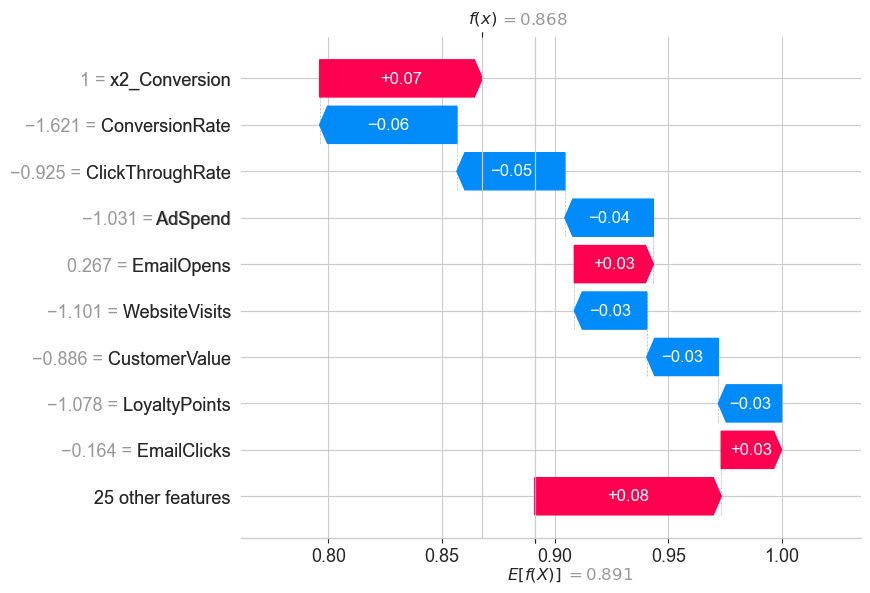

In [10]:
# Plot SHAP waterfall for a specific sample
sample_index = 0
shap.plots.waterfall(shap_values[sample_index, :, 1])

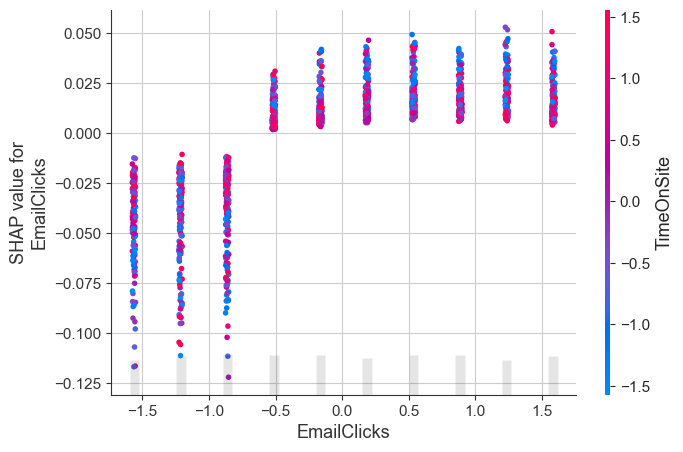

In [11]:
# Plot SHAP dependence for a specific feature
shap.plots.scatter(
    shap_values[:, "EmailClicks", 1],
    color=shap_values[:, "TimeOnSite", 1]
)

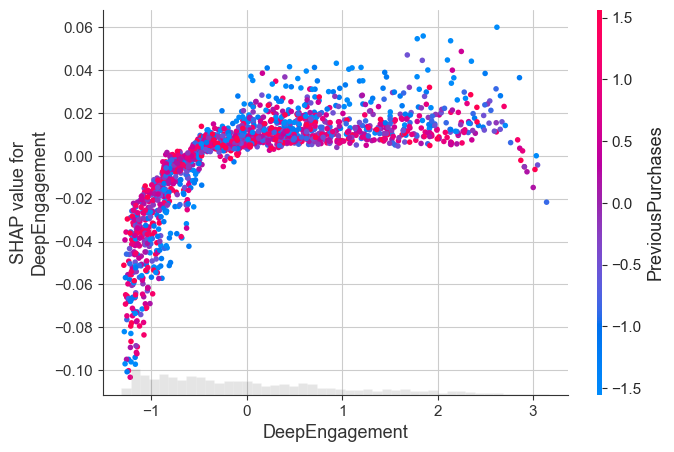

In [12]:
# Plot SHAP dependence for another feature
shap.plots.scatter(
    shap_values[:, "DeepEngagement", 1],
    color=shap_values[:, "PreviousPurchases", 1]
)

In [13]:
# Force plot for a specific sample
shap.initjs()

shap.plots.force(
    shap_values[sample_index, :, 1]
)

In [14]:
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_values[:, :, 1].values).mean(axis=0)
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
3,ClickThroughRate,0.030774
2,AdSpend,0.027979
9,EmailOpens,0.025060
10,EmailClicks,0.024014
4,ConversionRate,0.023013
7,TimeOnSite,0.021895
5,WebsiteVisits,0.019258
15,CustomerValue,0.019159
6,PagesPerVisit,0.018489
12,LoyaltyPoints,0.017665


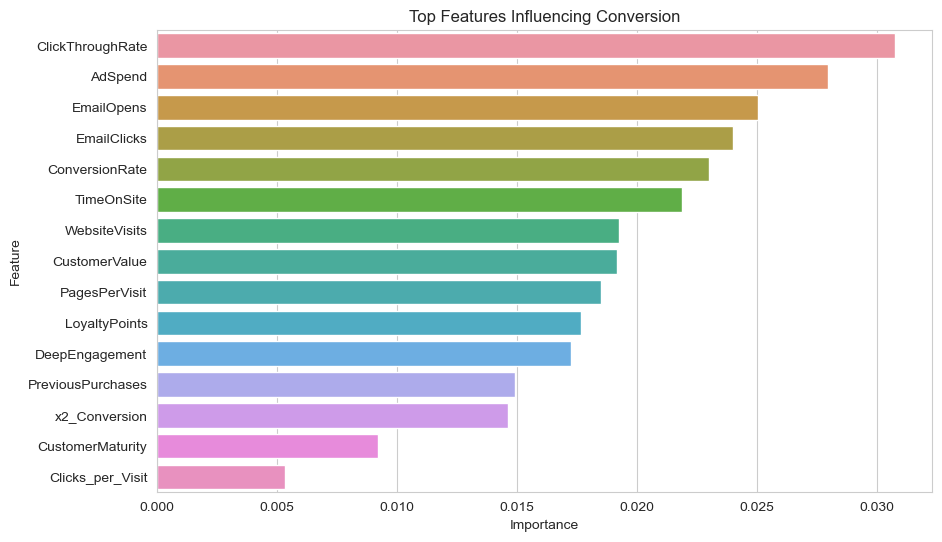

In [15]:
# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Conversion")
plt.show()

In [16]:
# Export SHAP feature importance to CSV
importance_df.to_csv(
    "D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/reports/shap_feature_importance.csv",
    index=False
)

print("✅ SHAP report exported!")

✅ SHAP report exported!
